In [1]:
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import healpy as hp
import pymaster as nmt
import numpy as np

In [3]:
from astropy.io import fits
import numpy as np

# Load the LoTSS DR3 catalogue
file_survey = 'LoTSS_DR3_v1.0.srl.fits'
with fits.open(file_survey) as hdulist:
    tbdata = hdulist[1].data
    
    # Extract coordinates in degrees
    RA = np.array(tbdata['RA'])
    DEC = np.array(tbdata['DEC'])


In [4]:
def pix_indices_of_ra_dec(ra_list, dec_list, nside, nest=False):
    """
    Converts celestial coordinates (RA/Dec) to HEALPix pixel indices.
    
    Args:
        ra_list (array-like): Right Ascension in degrees [0, 360].
        dec_list (array-like): Declination in degrees [-90, 90].
        nside (int): HEALPix resolution parameter.
        nest (bool): If True, use NESTED ordering. Otherwise, use RING.

    Returns:
        np.ndarray: Array of pixel indices corresponding to each coordinate pair.
    """
    # Ensure inputs are treated as numpy arrays for vectorization
    ra_list = np.asarray(ra_list)
    dec_list = np.asarray(dec_list)
    
    # Transform to HEALPix spherical coordinates: 
    # Colatitude theta (0 to pi) and Azimuth phi (0 to 2pi)
    theta = np.radians(90.0 - dec_list) 
    phi = np.radians(ra_list)
    
    return hp.ang2pix(nside, theta, phi, nest=nest)

def create_healpix_map(ra_list, dec_list, nside, nest=False, weights=np.array([])):
    """
    Generates a HEALPix map from a catalog of RA and Dec positions.
    
    If weights are provided, the map represents the sum of weights per pixel.
    If no weights are provided, the map represents a simple counts (occupancy) map.
    
    Parameters:
        ra_list (array-like): Right Ascension values in degrees.
        dec_list (array-like): Declination values in degrees.
        nside (int): HEALPix resolution (must be a power of 2).
        nest (bool): Ordering scheme (True=NESTED, False=RING).
        weights (np.ndarray): Optional array of weights for each object.
        
    Returns:
        np.ndarray: A 1D array of length 12 * nside**2 representing the map.
    """
    # Map each object to its respective pixel index
    pix_indices = pix_indices_of_ra_dec(ra_list, dec_list, nside, nest)
    npix = hp.nside2npix(nside)
    
    # Case 1: Simple object counts (unweighted)
    if weights is None or weights.size == 0:
        return np.bincount(pix_indices, minlength=npix).astype(np.float64)
    
    # Case 2: Weighted sum per pixel (e.g., intensity, mass, or average values)
    # Ensure weights match the number of objects
    if len(weights) != len(pix_indices):
        raise ValueError("The length of 'weights' must match the length of RA/Dec lists.")
        
    healpix_map = np.bincount(pix_indices, weights=weights, minlength=npix).astype(np.float64)
    
    return healpix_map


In [5]:
print(pix_indices_of_ra_dec(RA, DEC, 1024))
map=create_healpix_map(RA, DEC, 1024)

[2484224 4155392 3975168 ... 2123776 1618199 5474304]


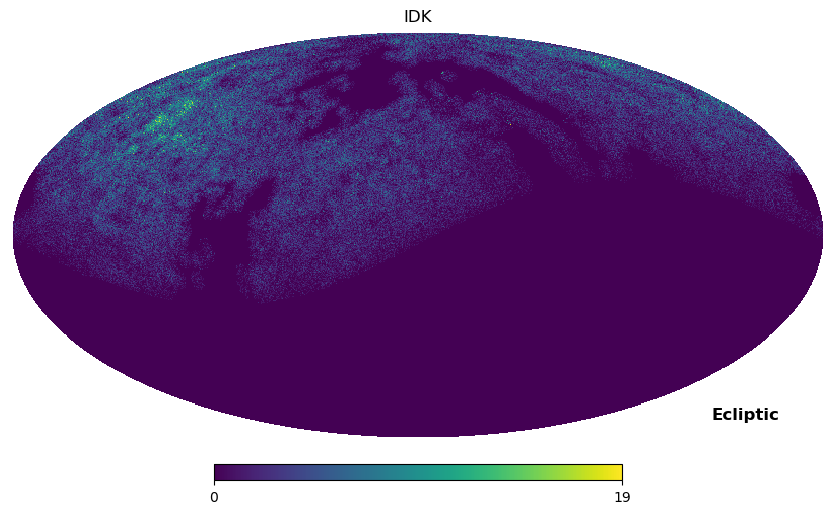

In [6]:
hp.mollview(map, coord=["C", "E"],title="IDK")

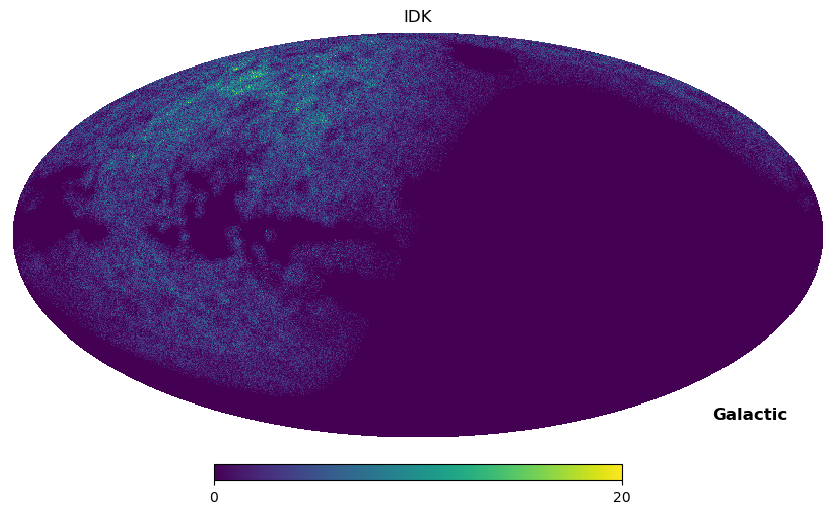

In [7]:
hp.mollview(map, coord=["E", "G"],title="IDK")

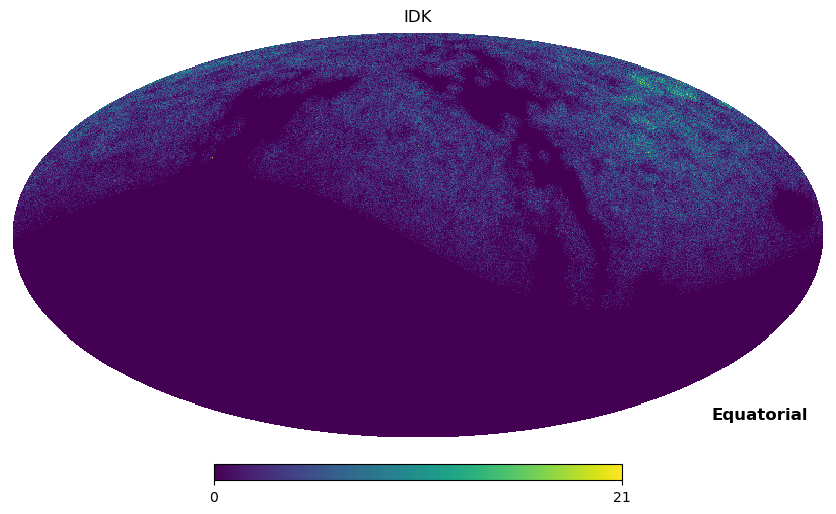

In [8]:
hp.mollview(map, coord=["E", "C"],title="IDK")

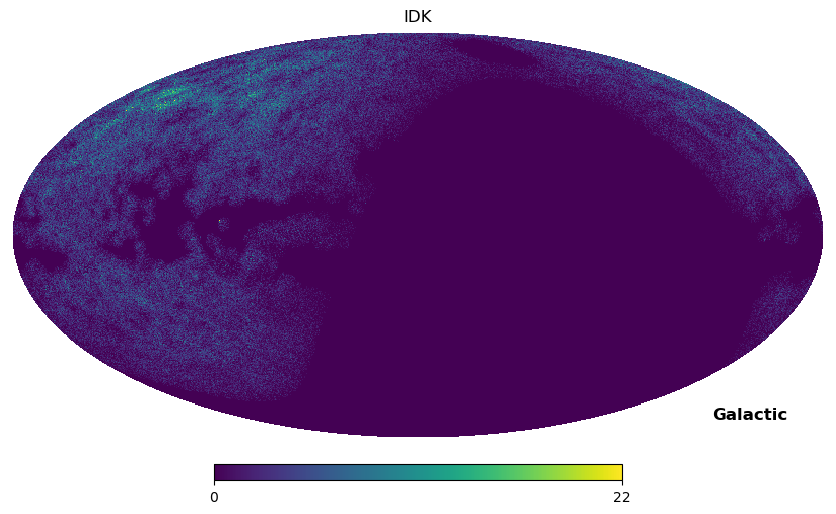

In [9]:
hp.mollview(map, coord=["C", "G"],title="IDK")

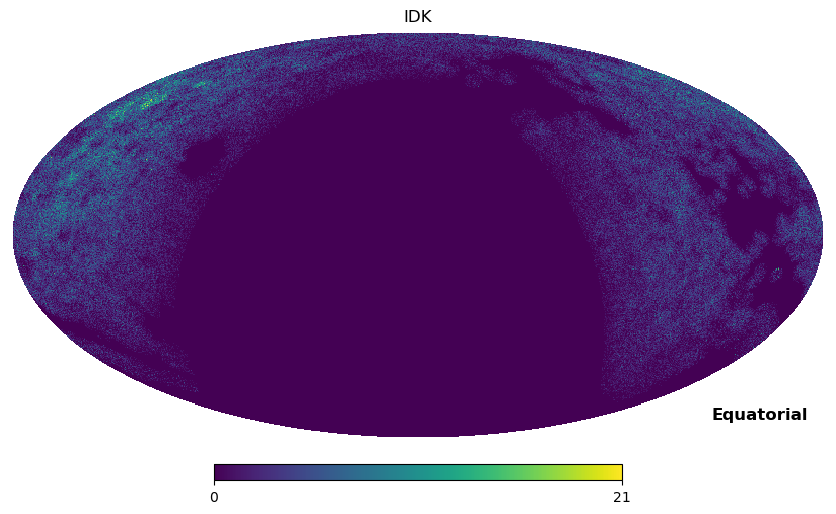

In [10]:
hp.mollview(map, coord=["G", "C"],title="IDK")

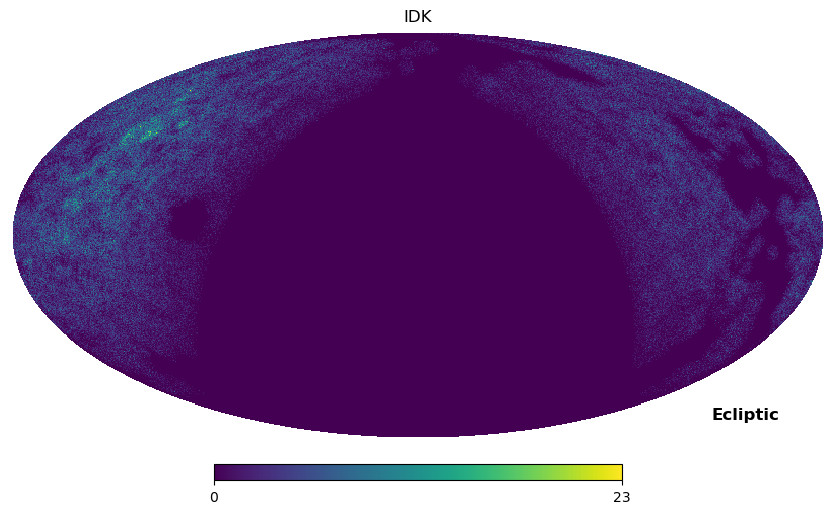

In [11]:
hp.mollview(map, coord=["G", "E"],title="IDK") # those look like something, maybe i have to rotate them somehow 

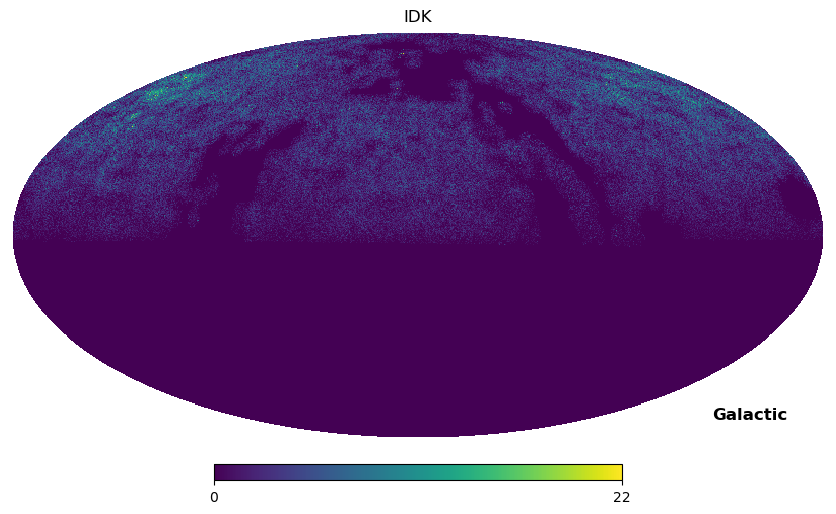

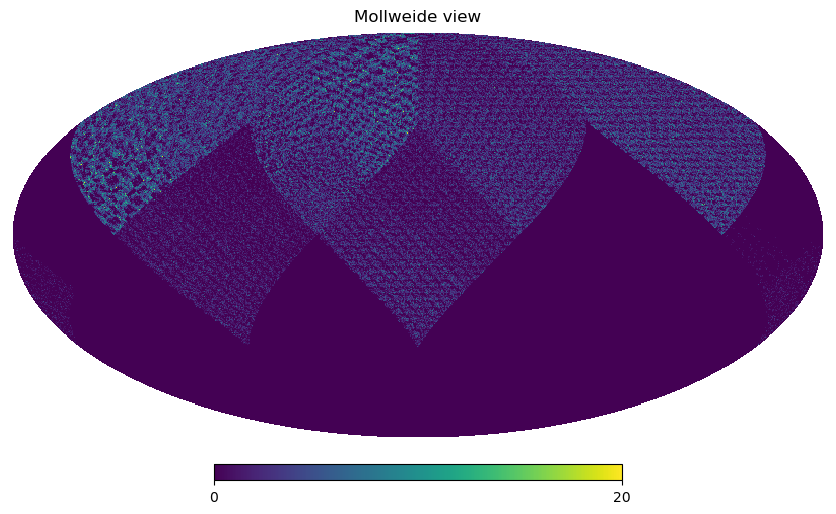

In [12]:
hp.mollview(map, coord=["G", "G"],title="IDK") 
hp.mollview(map, nest=True) #still look like nothing 

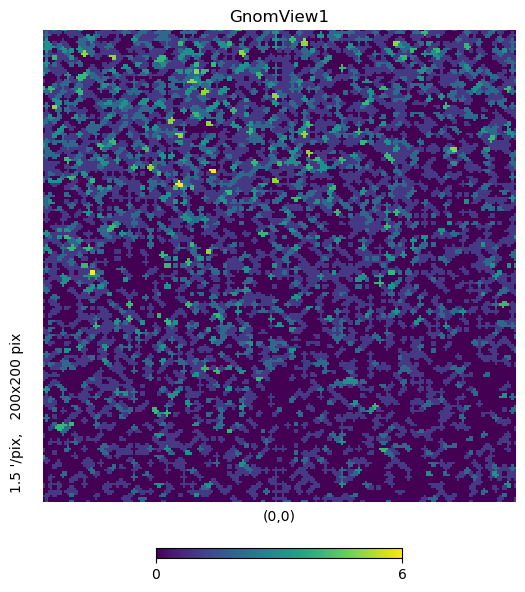

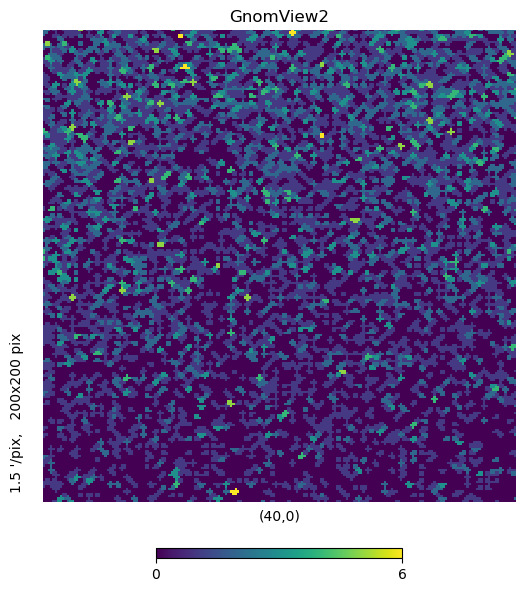

In [13]:
hp.gnomview(map, rot=[0,0], title="GnomView1")
hp.gnomview(map, rot=[40,0], title="GnomView2")

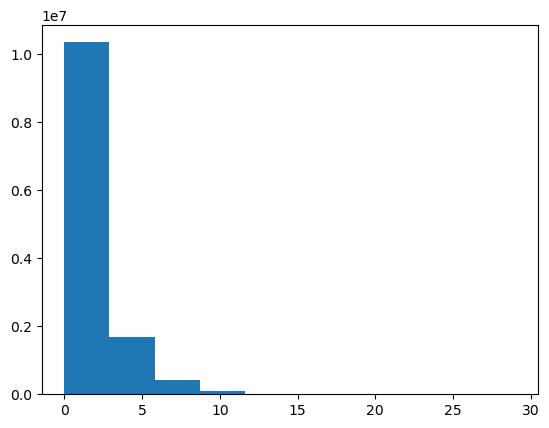

In [14]:
plt.hist(map, bins=10 ); #UNITS? how do i insert them, where do i reed what units there is?

In [15]:
LMAX = 2048
cl = hp.anafast(map, lmax=LMAX)
ell = np.arange(len(cl))


<>:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/tmp/ipykernel_678/1438154512.py:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.xlabel("$\ell$")
/tmp/ipykernel_678/1438154512.py:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.

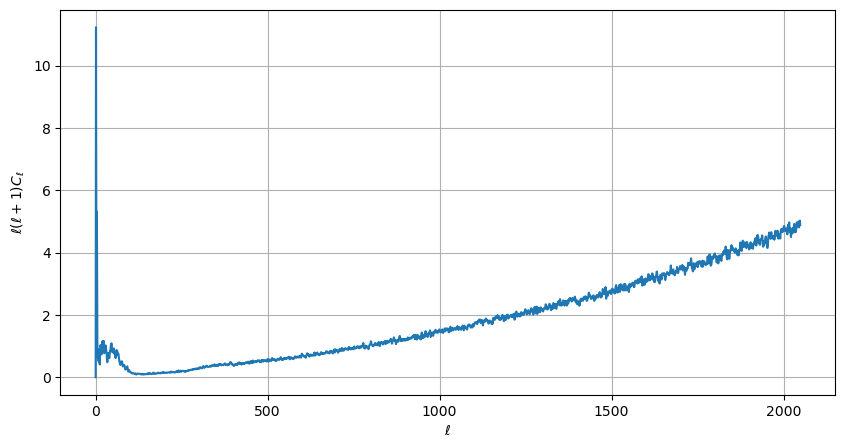

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(ell, ell * (ell + 1) * cl)
plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)C_{\ell}$")
plt.grid()
hp.write_cl("cl.fits", cl, overwrite=True)

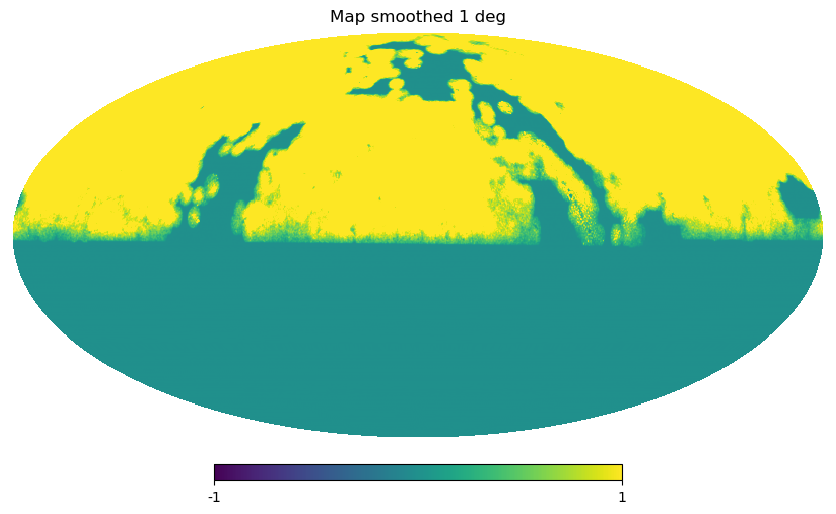

In [17]:
map_smooth = hp.smoothing(map, fwhm=np.radians(.5))
hp.mollview(map_smooth, min=-1, max=1, title="Map smoothed .5 deg") #mmmh, maybe that's wrong...

In [18]:
LMAX = 1024
cl = hp.anafast(map, lmax=LMAX)
ell = np.arange(len(cl))

<>:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/tmp/ipykernel_678/1438154512.py:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.xlabel("$\ell$")
/tmp/ipykernel_678/1438154512.py:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.

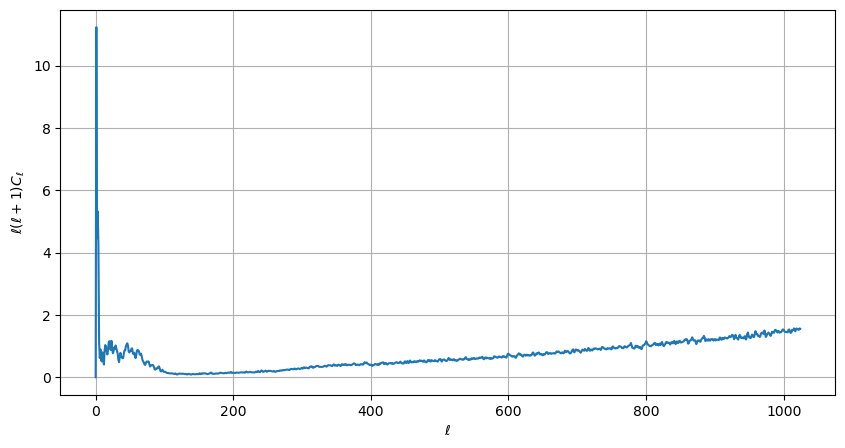

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(ell, ell * (ell + 1) * cl)
plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)C_{\ell}$")
plt.grid()
hp.write_cl("cl.fits", cl, overwrite=True)

In [20]:
LMAX = 128
cl = hp.anafast(map, lmax=LMAX)
ell = np.arange(len(cl))

<>:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/tmp/ipykernel_678/1438154512.py:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.xlabel("$\ell$")
/tmp/ipykernel_678/1438154512.py:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.

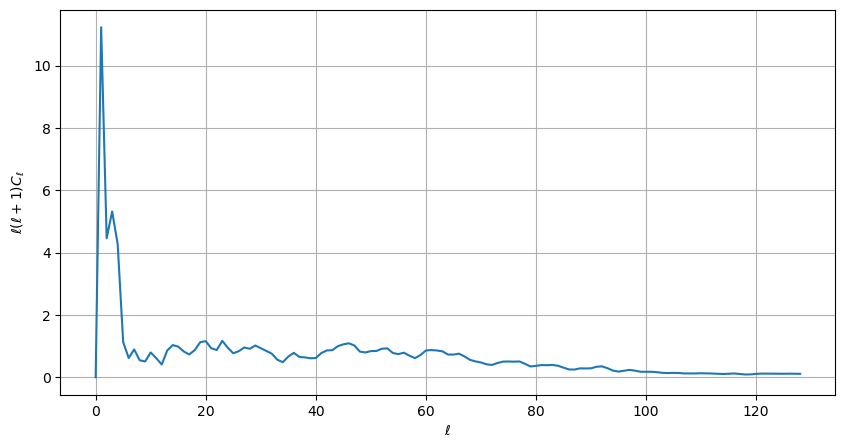

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(ell, ell * (ell + 1) * cl)
plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)C_{\ell}$")
plt.grid()
hp.write_cl("cl.fits", cl, overwrite=True)

In [22]:
import pymaster as nmt

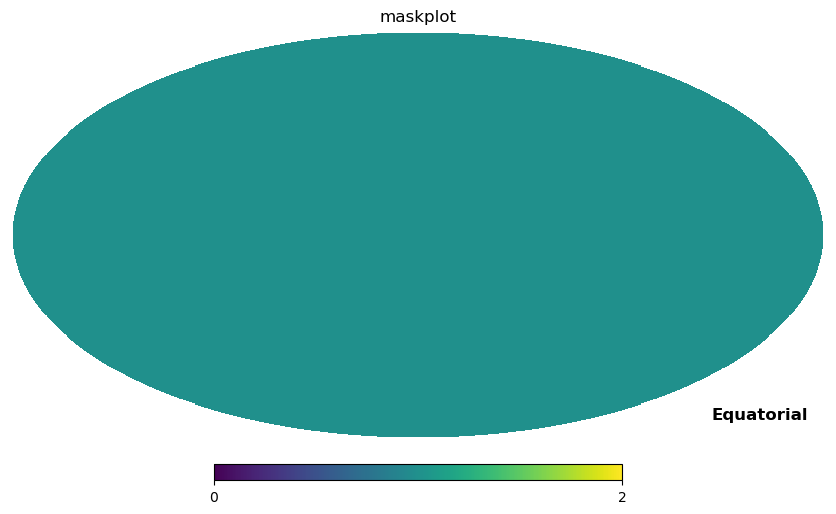

In [38]:
binning = nmt.NmtBin.from_nside_linear(nside=hp.get_nside(map), nlb=1)
mask = hp.mask_good(map)
field = nmt.NmtField(mask, [map])
cl_master = nmt.compute_full_master(field, field, binning)
hp.mollview(mask, coord=["C", "C"],title="maskplot") #it is supposed to be like this?


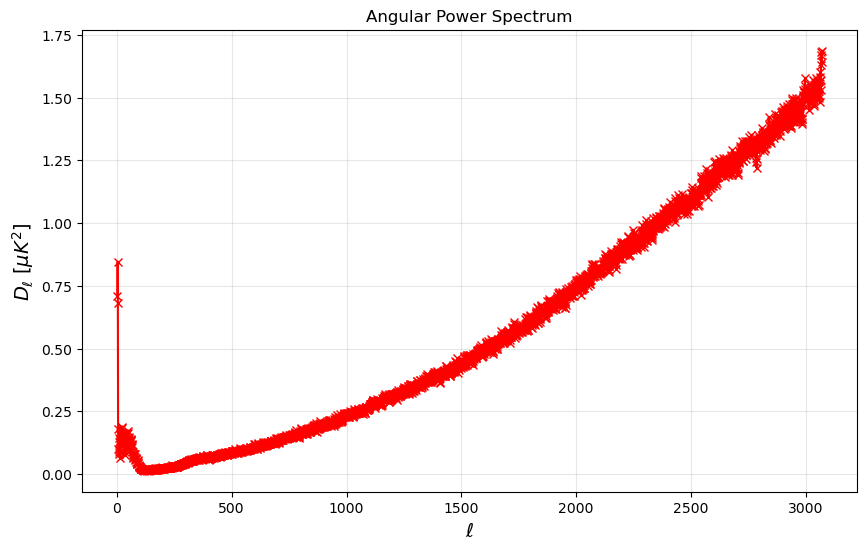

In [36]:
ell_effective = binning.get_effective_ells()
cl_values = cl_master[0]
plt.figure(figsize=(10, 6))
dl_values = ell_effective * (ell_effective + 1) * cl_values / (2 * np.pi)

plt.plot(ell_effective, dl_values, 'x-', color='red')
plt.xlabel(r'$\ell$', fontsize=14)
plt.ylabel(r'$D_\ell$ $[\mu K^2]$', fontsize=14)
plt.title('Angular Power Spectrum')
plt.grid(True, alpha=0.3)
plt.show()